# Chapter 3 — Statistical Experiments and Significance Testing

## Learning Objectives

This notebook covers A/B testing, null and alternative hypotheses, permutation tests, p-values, t-tests, multiple testing, ANOVA, chi-square testing, multi-arm bandits, power, and sample size.

## Theoretical Explanation

Statistical experiments help determine whether observed differences are likely due to a treatment effect or random variation. A/B tests compare two treatments, ideally through random assignment. The null hypothesis assumes no real difference, and the alternative hypothesis represents the effect being investigated.

Permutation tests are useful because they construct the null distribution directly from the observed data by shuffling labels. A p-value measures how often the null model produces results as extreme as the observed statistic. It does not prove that the null hypothesis is true or false; it only measures compatibility with a chance model. For data science, this interpretation is more important than rigid threshold thinking.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. A/B Test with Permutation Test

Observed mean difference B-A: 11.333
Permutation p-value: 0.0003


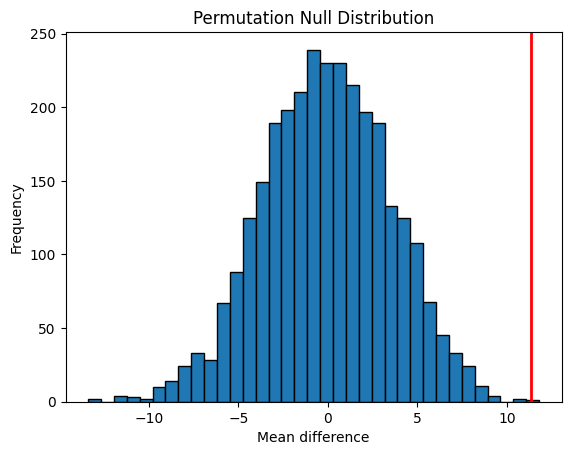

In [2]:
rng = np.random.RandomState(RANDOM_STATE)
A = rng.normal(loc=100, scale=15, size=40)
B = rng.normal(loc=108, scale=15, size=35)
observed = B.mean() - A.mean()
combined = np.r_[A, B]

perm_diffs = []
for _ in range(3000):
    shuffled = rng.permutation(combined)
    new_A = shuffled[:len(A)]
    new_B = shuffled[len(A):]
    perm_diffs.append(new_B.mean() - new_A.mean())
perm_diffs = np.array(perm_diffs)
p_value = np.mean(perm_diffs >= observed)

print('Observed mean difference B-A:', round(observed, 3))
print('Permutation p-value:', round(p_value, 4))
plt.hist(perm_diffs, bins=35, edgecolor='black')
plt.axvline(observed, color='red', linewidth=2)
plt.title('Permutation Null Distribution')
plt.xlabel('Mean difference')
plt.ylabel('Frequency')
plt.show()

### Output Interpretation

The histogram shows the range of mean differences expected under random label assignment. If the observed difference is far in the tail, chance is less plausible.

## 2. t-Test and Practical Interpretation

In [3]:
t_res = stats.ttest_ind(B, A, equal_var=False)
print('Welch t-statistic:', round(t_res.statistic, 4))
print('Two-sided p-value:', round(t_res.pvalue, 4))
print('One-sided p-value for B > A:', round(t_res.pvalue/2, 4))

Welch t-statistic: 3.4043
Two-sided p-value: 0.0011
One-sided p-value for B > A: 0.0005


### Output Interpretation

The t-test provides a formula-based approximation. The result should be interpreted with the effect size and practical context, not only by checking whether p < 0.05.

## 3. Chi-Square Test for Count Data

In [4]:
observed_table = np.array([[45, 55], [30, 70]])
chi2, p, dof, expected = stats.chi2_contingency(observed_table)
print('Observed table:\n', observed_table)
print('Expected counts:\n', np.round(expected, 2))
print('Chi-square:', round(chi2, 4))
print('p-value:', round(p, 4))
print('degrees of freedom:', dof)

Observed table:
 [[45 55]
 [30 70]]
Expected counts:
 [[37.5 62.5]
 [37.5 62.5]]
Chi-square: 4.1813
p-value: 0.0409
degrees of freedom: 1


### Output Interpretation

The chi-square test compares observed counts to expected counts under independence. A small p-value suggests the row and column variables may not be independent.

## 4. Simple Epsilon-Greedy Bandit Simulation

In [5]:
true_rates = np.array([0.04, 0.06, 0.05])
epsilon = 0.1
wins = np.zeros(3)
pulls = np.zeros(3)
choices = []
for t in range(1000):
    if rng.rand() < epsilon or np.any(pulls == 0):
        arm = rng.randint(3)
    else:
        arm = np.argmax(wins / np.maximum(pulls, 1))
    reward = rng.rand() < true_rates[arm]
    wins[arm] += reward
    pulls[arm] += 1
    choices.append(arm)
print('Pulls per arm:', pulls.astype(int))
print('Estimated rates:', np.round(wins / pulls, 4))
print('True rates:', true_rates)

Pulls per arm: [900  41  59]
Estimated rates: [0.03   0.0244 0.0169]
True rates: [0.04 0.06 0.05]


### Output Interpretation

The bandit increasingly favors the better-performing arm while still exploring alternatives. This is more adaptive than a fixed A/B/C allocation.

## Extended Study Notes

The most important professional habit in practical statistics is interpretation. A statistic is not useful only because it can be computed; it is useful when it answers a real question about data quality, uncertainty, relationships, prediction, or decision-making. In data science work, the same numerical result can have different meanings depending on the sampling process, the metric used, the business cost of errors, and the assumptions behind the procedure.

This notebook intentionally uses original, simplified examples instead of copying the book examples verbatim. The purpose is academic understanding: connect the statistical concept to a runnable Python workflow, inspect the output, and explain what the output means. This also supports academic integrity because the notebook demonstrates the learned concept in original wording and with adapted code.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, Python implementation, output interpretation, and practical data science context.

## Key Takeaways

- Statistical concepts should be connected to data science decisions, not treated as isolated formulas.
- Visual summaries and resampling methods often provide practical intuition beyond formula-based statistics.
- Model evaluation must consider uncertainty, bias, sampling, and the cost of incorrect conclusions.
- The output of code should always be interpreted in context before making decisions.